# Proyek Klasifikasi Gender CelebA

Notebook ini membangun model klasifikasi gambar **Male vs Not Male** menggunakan file atribut CelebA dan citra wajah yang sudah disejajarkan (*aligned face images*). Alur kerja disusun menjadi tahapan pemuatan data, EDA, prapemrosesan, pelatihan model, evaluasi, dan deployment sederhana.

## 1. Environment & Library

In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import cv2
import hashlib
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
import gradio as gr


import time
from torch.autograd import Variable
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt



c:\Users\gunna\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Source & Path

In [3]:
# data_path='drive/MyDrive/FaceRecognition/Dataset'
data_path=r"D:\iWork\course\faceRecognition\Dataset"

In [ ]:
# Optional Colab-only mount. Leave this commented when running locally.
# from google.colab import drive
# drive.mount('/content/drive')


In [6]:
images_list =os.path.join(data_path, "Images")
attr_list = os.path.join(data_path, "list_attribute.txt")


## 3. Load & Filter Dataset

In [7]:
def load_celeba_attributes(attr_path):
    with open(attr_path, "r", encoding="utf-8") as f:
        _n = int(f.readline().strip())
        attrs = f.readline().strip().split()

    df = pd.read_csv(
        attr_path,
        sep=r"\s+",
        engine="python",
        skiprows=2,
        header=None,
        names=["image_id"] + attrs,
        dtype={"image_id": str},
    )

    df["image_id"] = df["image_id"].astype(str)
    df["Male"] = (df["Male"] == 1).astype("int8")
    return df[["image_id", "Male"]]

In [8]:
# load the data
#data = # load data from file provided
#data =  # filter the data with available images only (5000 images)
# make sure image_id is a string (not a list)
# ✅ assign path

#print(type(data))
#print(data.head(3))
#print(type(data.iloc[0]["image_id"]), data.iloc[0]["image_id"])

# load the data
data = load_celeba_attributes(attr_list)
data["path"] = data["image_id"].apply(lambda x: os.path.join(images_list, x))

# filter the data with available images only (5000 images)
data = (
    data[data["path"].apply(os.path.exists)]
    .sample(n=5000, random_state=42)
    .reset_index(drop=True)
)

data.head()


,image_id,Male,path
0,060965.jpg,1,D:\iWork\course\faceRecognition\Dataset\Images...
1,103730.jpg,1,D:\iWork\course\faceRecognition\Dataset\Images...
2,107306.jpg,1,D:\iWork\course\faceRecognition\Dataset\Images...
3,042410.jpg,1,D:\iWork\course\faceRecognition\Dataset\Images...
4,028520.jpg,1,D:\iWork\course\faceRecognition\Dataset\Images...


## 4. Exploratory Data Analysis (EDA)

### 4.1 Label Distribution

4) Distribusi label (Male vs Not Male)

Male
0    2953
1    2047
Name: count, dtype: int64


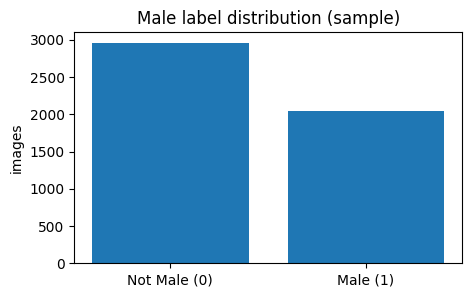

pct Male: 40.94 %


In [9]:
LABEL_COL = "Male"

counts = data[LABEL_COL].value_counts().sort_index()
print(counts)

plt.figure(figsize=(5,3))
plt.bar(["Not Male (0)", "Male (1)"], [counts.get(0,0), counts.get(1,0)])
plt.title("Male label distribution (sample)")
plt.ylabel("images")
plt.show()

pct_male = float(data[LABEL_COL].mean() * 100)
print("pct Male:", round(pct_male, 2), "%")

### 4.2 Image Quality & Basic Visual Statistics

#### Basic Scan Image: resolusi + kecerahan/kontras

Bagian ini memindai sampel dari 5000 gambar (atur `SCAN_N` untuk mengontrol jumlah sampel yang dianalisis).

In [10]:
def scan_images(df, scan_n=2000, seed=1):
    samp = df.sample(n=min(scan_n, len(df)), random_state=seed).copy()
    rows = []
    for p in tqdm(samp["path"].tolist(), desc="Scanning images"):
        row = {"path": p, "error":None }
        try:
            with Image.open(p) as im:
                im = im.convert("RGB")
                w, h = im.size
                # brightness/contrast proxy using PIL getextrema + convert to grayscale
                gray = im.convert("L")
                # mean/std without numpy: use histogram
                hist = gray.histogram()  # 256 bins
                total = sum(hist)
                mean = sum(i * hist[i] for i in range(256)) / total if total else 0

                # variance = E[x^2] - mean^2
                ex2 = sum((i*i) * hist[i] for i in range(256)) / total if total else 0
                var = max(0.0, ex2 - mean*mean)
                std = var ** 0.5

                row.update({
                    "width": w,
                    "height": h,
                    "aspect": (w / h) if h else None,
                    "mean_gray": float(mean),
                    "std_gray": float(std),
                })
        except Exception as e:
            row["error"] = str(e)
        rows.append(row)

    stats = pd.DataFrame(rows)
    out = samp.merge(stats, on="path", how="left")
    return out

SCAN_N = 2000
img_stats = scan_images(data, scan_n=SCAN_N)
print("Scan errors:", img_stats["error"].notna().sum())
ok = img_stats[img_stats["error"].isna()].copy()
ok.head()

#print("Scan errors:", img_stats)

Scanning images:   0%|          | 0/2000 [00:00<?, ?it/s]

Scanning images: 100%|██████████| 2000/2000 [00:18<00:00, 107.12it/s]

Scan errors: 0


,image_id,Male,path,error,width,height,aspect,mean_gray,std_gray
0,147857.jpg,0,D:\iWork\course\faceRecognition\Dataset\Images...,None,178,218,0.816514,55.735775,50.082251
1,158162.jpg,0,D:\iWork\course\faceRecognition\Dataset\Images...,None,178,218,0.816514,101.181811,78.836028
2,054207.jpg,0,D:\iWork\course\faceRecognition\Dataset\Images...,None,178,218,0.816514,189.166065,77.693290
3,055107.jpg,1,D:\iWork\course\faceRecognition\Dataset\Images...,None,178,218,0.816514,162.506391,49.909053
4,187928.jpg,0,D:\iWork\course\faceRecognition\Dataset\Images...,None,178,218,0.816514,77.648954,50.686236


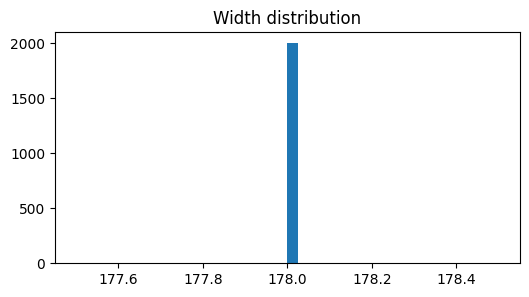

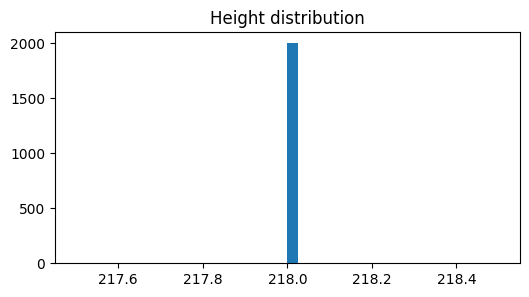

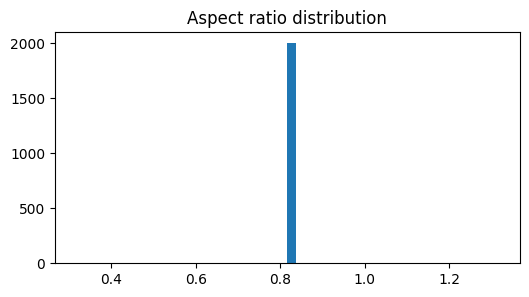

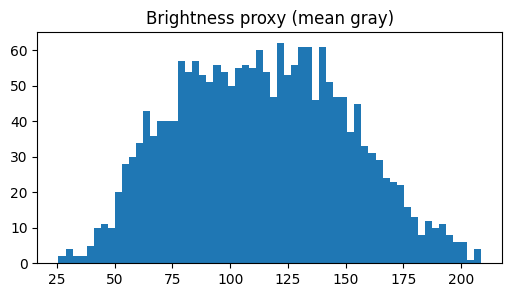

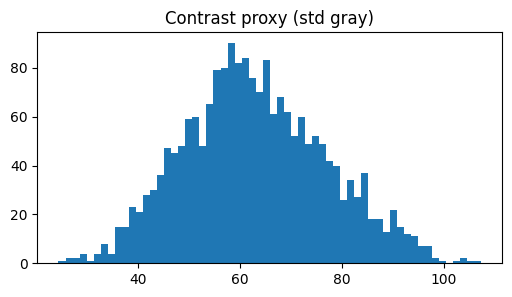

In [11]:
#PLOT DISTRIBUTION
plt.figure(figsize=(6,3))
plt.hist(ok["width"], bins=40)
plt.title("Width distribution")
plt.show()

plt.figure(figsize=(6,3))
plt.hist(ok["height"], bins=40)
plt.title("Height distribution")
plt.show()

plt.figure(figsize=(6,3))
plt.hist(ok["aspect"].dropna(), bins=50)
plt.title("Aspect ratio distribution")
plt.show()

plt.figure(figsize=(6,3))
plt.hist(ok["mean_gray"], bins=60)
plt.title("Brightness proxy (mean gray)")
plt.show()

plt.figure(figsize=(6,3))
plt.hist(ok["std_gray"], bins=60)
plt.title("Contrast proxy (std gray)")
plt.show()

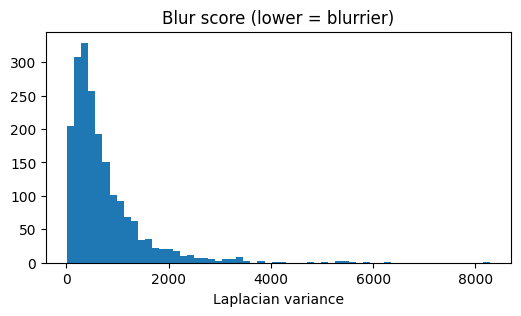

In [12]:
#BLUR DETECTION
def blur_score(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return float(cv2.Laplacian(img, cv2.CV_64F).var())

# compute blur for scanned subset only
ok["blur"] = ok["path"].map(blur_score)

plt.figure(figsize=(6,3))
plt.hist(ok["blur"].dropna(), bins=60)
plt.title("Blur score (lower = blurrier)")
plt.xlabel("Laplacian variance")
plt.show()

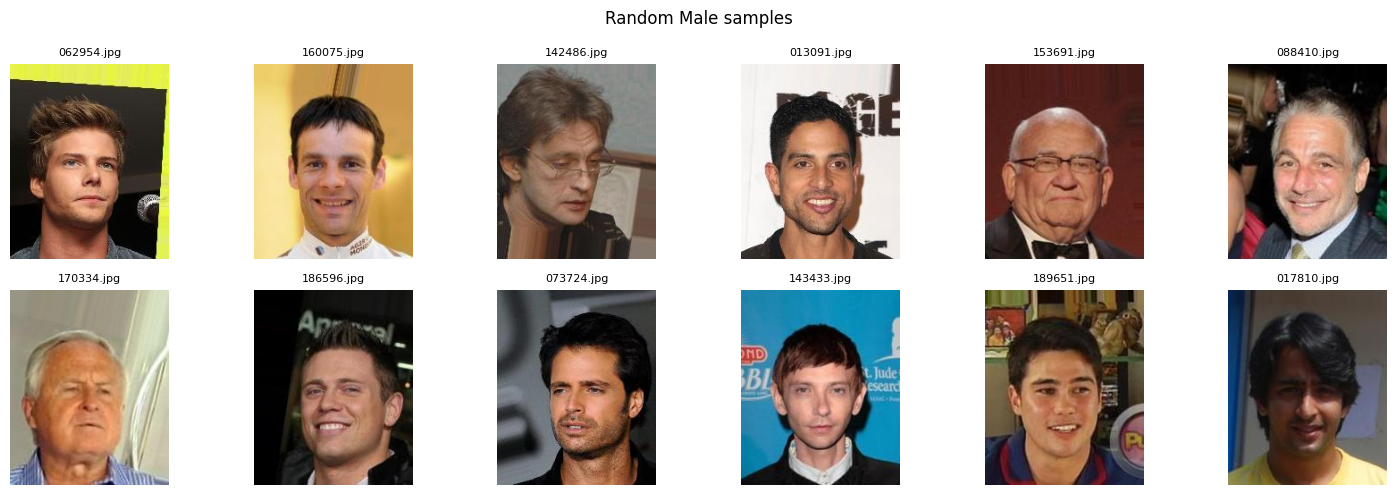

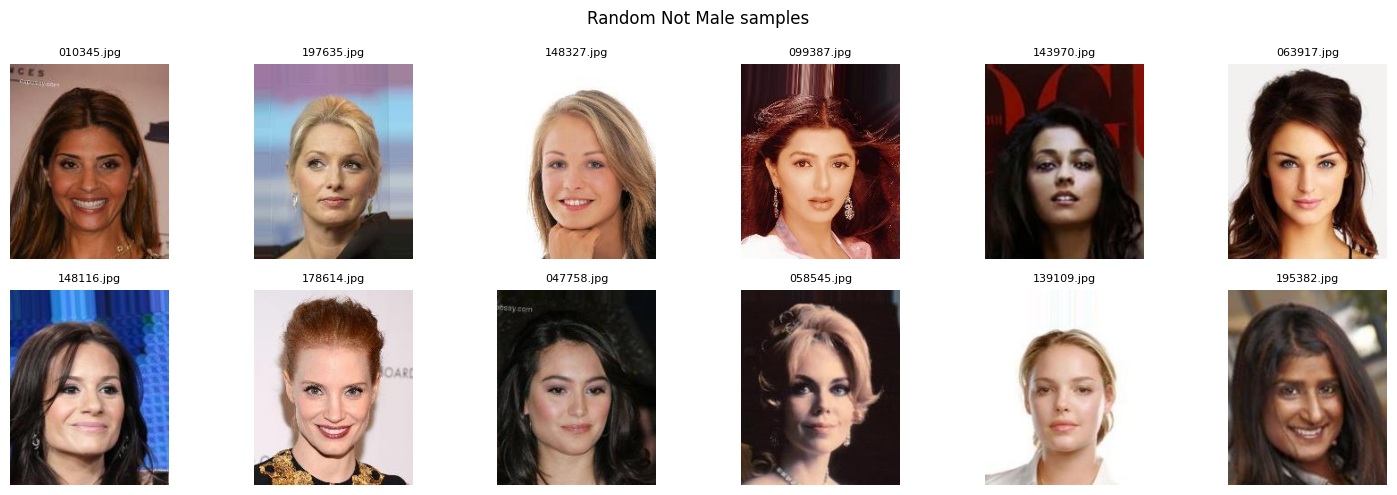

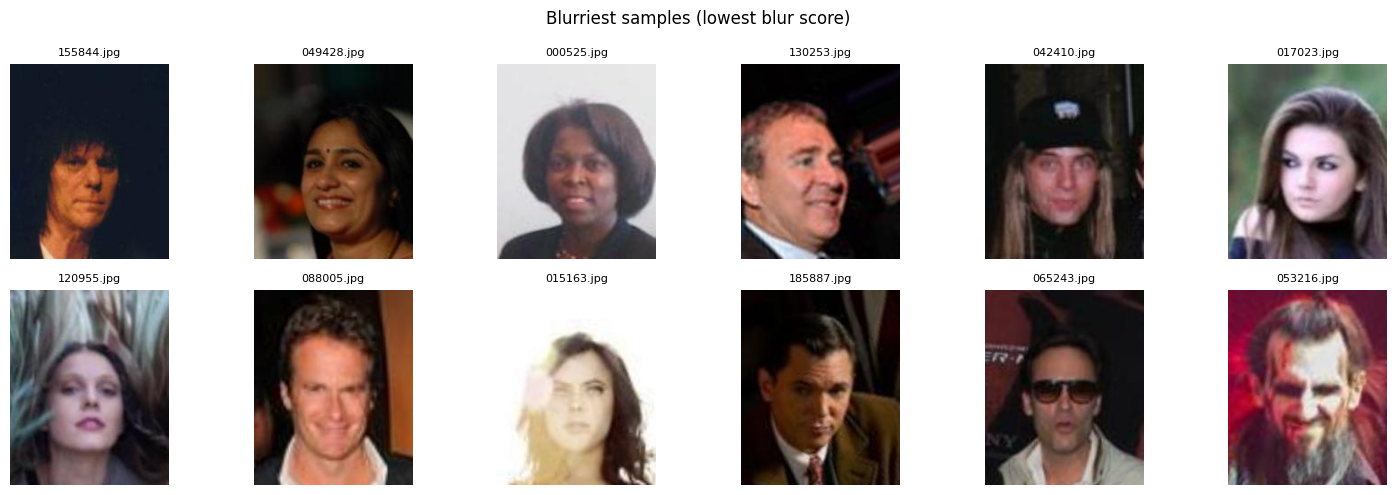

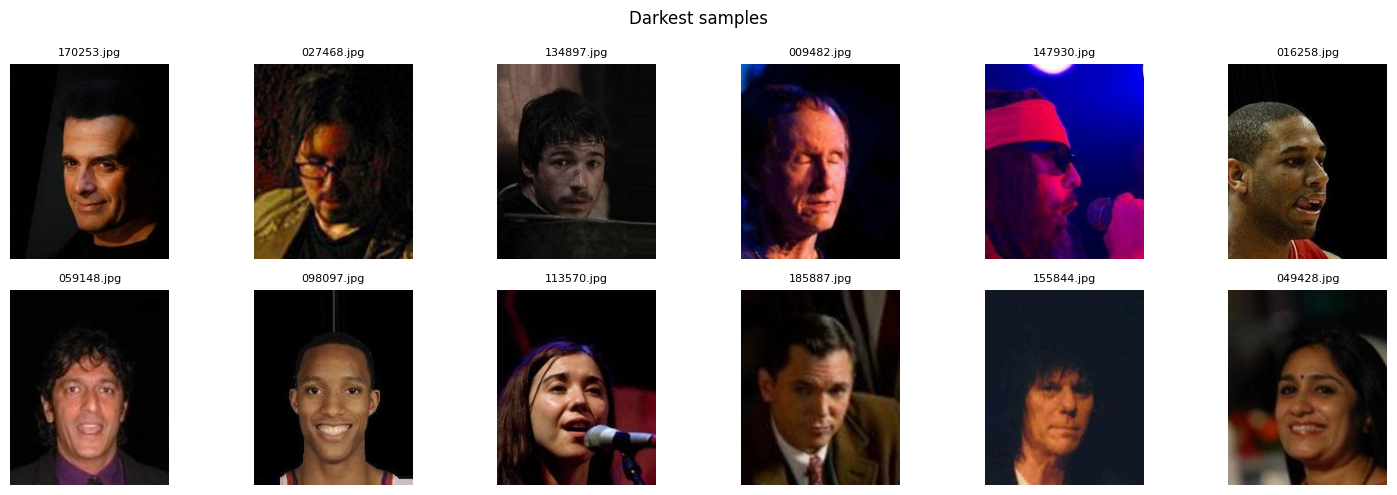

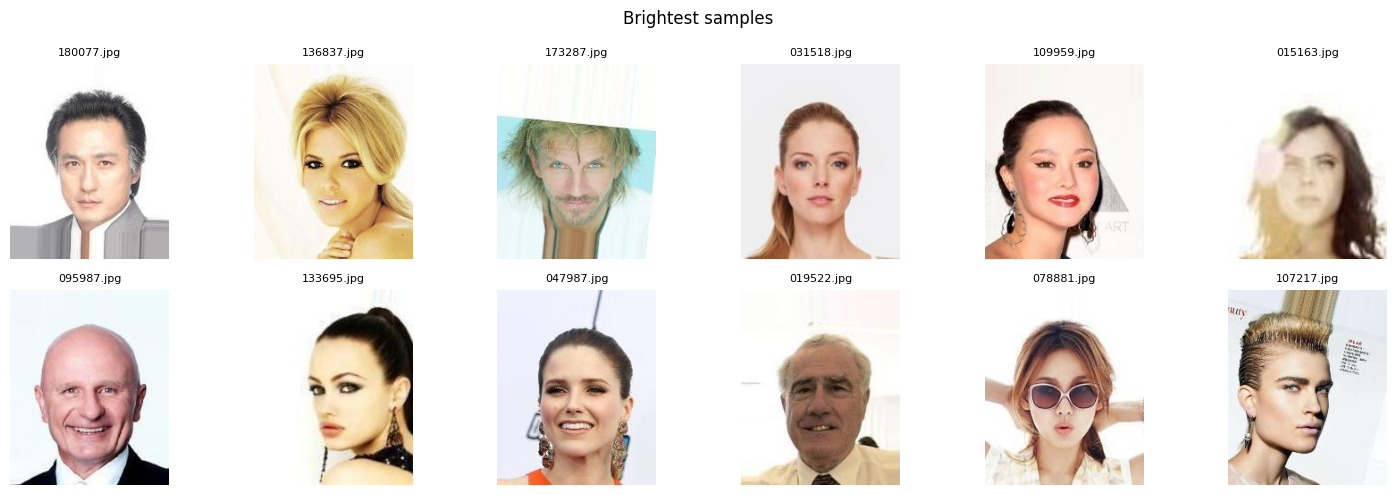

In [13]:
#Visual inspection grids (random + edge cases)
from math import ceil

def show_grid(paths, title, cols=6, size=2.5):
    paths = list(paths)
    n = len(paths)
    rows = ceil(n / cols)
    plt.figure(figsize=(cols*size, rows*size))
    for i, p in enumerate(paths):
        plt.subplot(rows, cols, i+1)
        im = Image.open(p).convert("RGB")
        plt.imshow(im)
        plt.axis("off")
        plt.title(os.path.basename(p)[:18], fontsize=8)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# random samples by label
male_paths = data[data[LABEL_COL]==1].sample(n=min(12, (data[LABEL_COL]==1).sum()), random_state=1)["path"]
fem_paths  = data[data[LABEL_COL]==0].sample(n=min(12, (data[LABEL_COL]==0).sum()), random_state=1)["path"]

show_grid(male_paths, "Random Male samples")
show_grid(fem_paths, "Random Not Male samples")

# edge cases from scanned subset
darkest   = ok.nsmallest(12, "mean_gray")["path"]
brightest = ok.nlargest(12, "mean_gray")["path"]
if "blur" in ok.columns:
    blurriest = ok.nsmallest(12, "blur")["path"]
    show_grid(blurriest, "Blurriest samples (lowest blur score)")

show_grid(darkest, "Darkest samples")
show_grid(brightest, "Brightest samples")

### 4.3 Bias Atribut dan Pemeriksaan Duplikasi

,attr,corr_with_male


,attr,corr_with_male


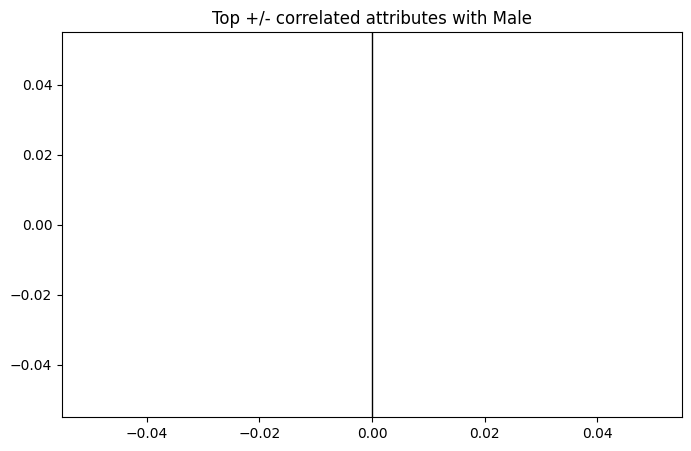

In [14]:
# Attribute bias: which attributes correlate with Male

# compute correlation to Male for all other attributes (binary)
attr_cols = [c for c in data.columns if c not in ["image_id", "path", LABEL_COL]]

corrs = []
for c in attr_cols:
    # pandas corr; both are 0/1
    corr = data[[LABEL_COL, c]].corr().iloc[0,1]
    corrs.append((c, float(corr) if pd.notna(corr) else 0.0))

corr_df = pd.DataFrame(corrs, columns=["attr", "corr_with_male"]).sort_values("corr_with_male", ascending=False)
display(corr_df.head(15))
display(corr_df.tail(15))

# plot top +/- correlations
top = pd.concat([corr_df.head(10), corr_df.tail(10)])
plt.figure(figsize=(8,5))
plt.barh(top["attr"], top["corr_with_male"])
plt.title("Top +/- correlated attributes with Male")
plt.axvline(0, color="black", linewidth=1)
plt.show()

In [15]:
#conditional rates
def cond_rate(df, attr):
    p_male = df[df[LABEL_COL]==1][attr].mean()
    p_fem  = df[df[LABEL_COL]==0][attr].mean()
    return float(p_male), float(p_fem), float(p_male - p_fem)

focus_attrs = [
    "No_Beard","Mustache","Goatee","Sideburns",
    "Wearing_Lipstick","Heavy_Makeup","Wearing_Earrings",
    "Bald","Bangs","Eyeglasses","Wearing_Hat","Young","Smiling"
]

rows = []
for a in focus_attrs:
    if a in data.columns:
        pm, pf, diff = cond_rate(data, a)
        rows.append([a, pm, pf, diff])

cond_df = pd.DataFrame(rows, columns=["attr","P(attr=1|Male=1)","P(attr=1|Male=0)","diff"]).sort_values("diff", ascending=False)
display(cond_df)

,attr,P(attr=1|Male=1),P(attr=1|Male=0),diff


In [16]:
#duplicate check

def md5_file(path, chunk=1<<20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b: break
            h.update(b)
    return h.hexdigest()

sample_paths = data.sample(n=min(2000, len(data)), random_state=7)["path"].tolist()
seen = {}
dups = []
for p in tqdm(sample_paths, desc="MD5 duplicates"):
    h = md5_file(p)
    if h in seen:
        dups.append((seen[h], p))
    else:
        seen[h] = p

print("Exact duplicate pairs in sample:", len(dups))
if dups:
    show_grid([dups[0][0], dups[0][1]], "Example exact duplicate pair", cols=2)

MD5 duplicates: 100%|██████████| 2000/2000 [00:12<00:00, 158.19it/s]

Exact duplicate pairs in sample: 0


In [17]:
# near Duplicate check

def phash(path):
    try:
        return str(imagehash.phash(Image.open(path).convert("RGB")))
    except Exception:
        return None

sample_paths = data.sample(n=min(1500, len(data)), random_state=9)["path"].tolist()
seen = {}
near = []
for p in tqdm(sample_paths, desc="pHash near-duplicates"):
    h = phash(p)
    if not h:
        continue
    if h in seen:
        near.append((seen[h], p))
    else:
        seen[h] = p

print("Near-duplicate candidates (same pHash) in sample:", len(near))
if near:
    show_grid([near[0][0], near[0][1]], "Example near-duplicate candidate", cols=2)

pHash near-duplicates: 100%|██████████| 1500/1500 [00:00<00:00, 380815.69it/s]

Near-duplicate candidates (same pHash) in sample: 0


In [18]:
#SUMMARY

summary = {
    "n_rows_used": int(len(data)),
    "pct_male": round(float(data["Male"].mean() * 100), 2),
    "scan_n": int(len(ok)),
    "scan_width_mean": round(float(ok["width"].mean()), 2),
    "scan_height_mean": round(float(ok["height"].mean()), 2),
    "brightness_mean_avg": round(float(ok["mean_gray"].mean()), 2),
    "contrast_std_avg": round(float(ok["std_gray"].mean()), 2),
}
summary

{'n_rows_used': 5000,
 'pct_male': 40.94,
 'scan_n': 2000,
 'scan_width_mean': 178.0,
 'scan_height_mean': 218.0,
 'brightness_mean_avg': 113.96,
 'contrast_std_avg': 63.07}

## 5. Membagi Dataset

In [ ]:
# Split the dataset into train and test sets (80:20), stratified by label
train_data, test_data = train_test_split(
    data,
    test_size=0.2,
    random_state=42,
    stratify=data["Male"],
)

print("Train size:", len(train_data))
print("Test size:", len(test_data))


## 6. Kelas Dataset dan Transformasi Gambar

In [20]:
class GenderDataset(Dataset):
    def __init__(self, data, image_folder_path, transform=None):
        self.data = data.reset_index(drop=True)
        self.image_folder_path = image_folder_path
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        filename = self.data.iloc[idx, 0]          # image_id
        gender   = int(self.data.iloc[idx, 1])     # Male 0/1

        image_path = os.path.join(self.image_folder_path, filename)

        # ✅ load image and convert to RGB
        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(gender, dtype=torch.float32)  # for BCEWithLogitsLoss

In [21]:
IMG_SIZE = 224

# option 1
#transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),])

#option 2
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),

    # mild color/lighting changes (safe for faces)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.02),

    # small tilt only
    transforms.RandomRotation(degrees=8),

    transforms.ToTensor(),

    # VGG pretrained expects ImageNet normalization
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),

    # optional: helps reduce shortcut learning (makeup/beard cues)
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3), value="random"),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [22]:
train_set = GenderDataset(train_data, images_list, transform=train_transform)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=0,pin_memory=True)

test_set = GenderDataset(test_data,images_list, transform=test_transform)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False, num_workers=0,pin_memory=True)

## 7. Setup Model (VGG16, Optimizer, dan Loss)

In [23]:
# please define the model optimizer and criterion (loss function)

# model = None
# optimizer = None
# criterion = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# please define the model optimizer and criterion (loss function)
model = models.vgg16(pretrained=True)

# replace the last layer to output 1 logit (binary)
in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, 1)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)


c:\Users\gunna\.venv312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\gunna\.venv312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 8. Model Training

In [ ]:
def train_model(model, dataloaders, dataset_sizes, criterion, optimizer,
                use_gpu=torch.cuda.is_available(), num_epochs=2):

    since = time.time()
    device = torch.device("cuda" if use_gpu and torch.cuda.is_available() else "cpu")
    model = model.to(device)

    phases = [p for p in ["train", "val", "test"] if p in dataloaders]
    if "train" not in phases:
        raise ValueError("dataloaders must contain a 'train' key")

    best_model_wts = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    best_acc = 0.0
    tracked_phase = "val" if "val" in phases else ("test" if "test" in phases else "train")

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 30)

        for phase in phases:
            is_train = phase == "train"
            model.train() if is_train else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device).float()
                if labels.ndim == 1:
                    labels = labels.unsqueeze(1)

                optimizer.zero_grad()

                with torch.set_grad_enabled(is_train):
                    logits = model(inputs)
                    if logits.ndim == 1:
                        logits = logits.unsqueeze(1)

                    loss = criterion(logits, labels)
                    probs = torch.sigmoid(logits)
                    preds = (probs >= 0.5).long()

                    if is_train:
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds.eq(labels.long())).item()

            denom = dataset_sizes.get(phase, len(dataloaders[phase].dataset))
            epoch_loss = running_loss / denom
            epoch_acc = running_corrects / denom

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == tracked_phase and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print()

    time_elapsed = time.time() - since
    print(f"Training complete in {int(time_elapsed // 60)}m {int(time_elapsed % 60)}s")
    print(f"Best {tracked_phase} Acc: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model


In [ ]:
dataloaders = {
    "train": train_loader,
    "test": test_loader,
}

dataset_sizes = {
    "train": len(train_set),
    "test": len(test_set),
}


In [ ]:
use_gpu = torch.cuda.is_available()
model = train_model(model, dataloaders, dataset_sizes, criterion, optimizer, use_gpu, 2)


## 9. Model Evaluation

In [36]:
def evaluate_model(model, test_loader, target_labels=("Not Male", "Male"),
                   use_gpu=torch.cuda.is_available(), plot_roc=True):
    """
    Binary evaluation for models that output 1 logit per image.
    Returns accuracy, confusion matrix, precision/recall/F1, ROC-AUC and ROC curve points.
    """
    from sklearn.metrics import roc_auc_score, roc_curve  # requires scikit-learn
    import matplotlib.pyplot as plt

    device = torch.device("cuda" if use_gpu and torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    tn = fp = fn = tp = 0
    total = 0
    correct = 0

    all_probs = []
    all_true = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)

            labels = labels.to(device)
            if labels.ndim > 1:
                labels = labels.view(-1)

            y_true = labels.long()

            logits = model(inputs)
            if logits.ndim > 1:
                logits = logits.view(-1)

            probs = torch.sigmoid(logits)          # probability of class 1 (Male)
            y_pred = (probs >= 0.5).long()

            # totals
            total += y_true.numel()
            correct += (y_pred == y_true).sum().item()

            # confusion
            tn += ((y_true == 0) & (y_pred == 0)).sum().item()
            fp += ((y_true == 0) & (y_pred == 1)).sum().item()
            fn += ((y_true == 1) & (y_pred == 0)).sum().item()
            tp += ((y_true == 1) & (y_pred == 1)).sum().item()

            # ROC/AUC buffers (move to CPU)
            all_probs.extend(probs.detach().cpu().tolist())
            all_true.extend(y_true.detach().cpu().tolist())

    accuracy = correct / total if total else 0.0

    def safe_div(a, b):
        return a / b if b else 0.0

    precision_pos = safe_div(tp, tp + fp)
    recall_pos    = safe_div(tp, tp + fn)
    f1_pos        = safe_div(2 * precision_pos * recall_pos, precision_pos + recall_pos)

    precision_neg = safe_div(tn, tn + fn)
    recall_neg    = safe_div(tn, tn + fp)
    f1_neg        = safe_div(2 * precision_neg * recall_neg, precision_neg + recall_neg)

    cm = [[tn, fp],
          [fn, tp]]

    # ROC/AUC (guard against single-class edge case)
    roc_auc = None
    fpr = tpr = thresholds = None
    if len(set(all_true)) == 2:
        roc_auc = float(roc_auc_score(all_true, all_probs))
        fpr, tpr, thresholds = roc_curve(all_true, all_probs)

        if plot_roc:
            plt.figure()
            plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc:.4f})")
            plt.plot([0, 1], [0, 1], linestyle="--")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title("ROC Curve")
            plt.legend()
            plt.show()
    else:
        # happens if test set accidentally contains only 0s or only 1s
        roc_auc = float("nan")

    print("Confusion Matrix (rows=true, cols=pred):")
    print(f"           pred {target_labels[0]:>8}  pred {target_labels[1]:>8}")
    print(f"true {target_labels[0]:>8}    {tn:8d}      {fp:8d}")
    print(f"true {target_labels[1]:>8}    {fn:8d}      {tp:8d}")
    print()
    print(f"Accuracy: {accuracy:.4f}")
    print(f"{target_labels[1]} -> Precision: {precision_pos:.4f}, Recall: {recall_pos:.4f}, F1: {f1_pos:.4f}")
    print(f"{target_labels[0]} -> Precision: {precision_neg:.4f}, Recall: {recall_neg:.4f}, F1: {f1_neg:.4f}")
    print(f"ROC-AUC: {roc_auc if roc_auc is not None else 'n/a'}")

    return {
        "accuracy": accuracy,
        "confusion_matrix": cm,
        "precision_pos": precision_pos,
        "recall_pos": recall_pos,
        "f1_pos": f1_pos,
        "precision_neg": precision_neg,
        "recall_neg": recall_neg,
        "f1_neg": f1_neg,
        "roc_auc": roc_auc,
        "roc_curve": {"fpr": fpr, "tpr": tpr, "thresholds": thresholds},
        "counts": {"tn": tn, "fp": fp, "fn": fn, "tp": tp, "total": total},
    }

In [ ]:
metrics = evaluate_model(model, dataloaders['test'], ["Not Male", "Male"])
metrics


## 10. Save Train Model

In [38]:
SAVE_PATH = "vgg_gender_celeba.pth"

torch.save(
    {
        "model_name": "vgg16",
        "img_size": 224,
        "state_dict": model.state_dict(),
        "threshold": 0.5,
        "labels": ["Not Male", "Male"],
    },
    SAVE_PATH
)

print("Saved:", SAVE_PATH)

Saved: vgg_gender_celeba.pth


## 11. Memuat Model untuk Inferensi

In [39]:
def load_gender_model(ckpt_path, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    ckpt = torch.load(ckpt_path, map_location=device)

    # build same architecture
    if ckpt.get("model_name") == "vgg19":
        m = models.vgg19(pretrained=False)
    else:
        m = models.vgg16(pretrained=False)

    in_features = m.classifier[-1].in_features
    m.classifier[-1] = nn.Linear(in_features, 1)

    m.load_state_dict(ckpt["state_dict"])
    m.to(device)
    m.eval()

    img_size = ckpt.get("img_size", 224)
    labels = ckpt.get("labels", ["Not Male", "Male"])
    threshold = ckpt.get("threshold", 0.5)

    infer_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    return m, infer_transform, labels, threshold, device

model_inf, infer_transform, labels, threshold, device = load_gender_model("vgg_gender_celeba.pth")
print("Loaded on:", device)

C:\Users\gunna\AppData\Local\Temp\ipykernel_37640\2305522790.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)
c:\Users\g

Loaded on: cuda


## 12. Demo Gradio

In [40]:
def predict_gender(image: Image.Image):
    # image arrives as PIL Image (RGB)
    if image is None:
        return {"error": "No image provided"}

    img = image.convert("RGB")
    x = infer_transform(img).unsqueeze(0).to(device)  # [1,3,H,W]

    with torch.no_grad():
        logit = model_inf(x).view(-1)[0]
        prob_male = torch.sigmoid(logit).item()

    pred_idx = 1 if prob_male >= threshold else 0
    pred_label = labels[pred_idx]

    # return a label + both class confidences
    return {
        "prediction": pred_label,
        "prob_male": round(prob_male, 4),
        "prob_not_male": round(1.0 - prob_male, 4),
    }

demo = gr.Interface(
    fn=predict_gender,
    inputs=gr.Image(type="pil", label="Upload face image"),
    outputs=gr.JSON(label="Result"),
    title="CelebA Gender Classifier (VGG)",
    description="Upload an image and the model predicts Male / Not Male with confidence."
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
